In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

print("Libraries loaded")

Libraries loaded


In [2]:
df = pd.read_csv("data/raw/Smart_City_index_headers.csv")

df.head()

,Id,City,Country,Smart_Mobility,Smart_Environment,Smart_Government,Smart_Economy,Smart_People,Smart_Living,SmartCity_Index,SmartCity_Index_relative_Edmonton
0,1,Oslo,Norway,6480,6512,7516,4565,8618,9090,7138,666
1,2,Bergen,Norway,7097,6876,7350,4905,8050,9090,7296,823
2,3,Amsterdam,Netherlands,7540,5558,8528,8095,7098,7280,7311,839
3,4,Copenhagen,Denmark,7490,7920,8726,5580,5780,7200,7171,698
4,5,Stockholm,Sweden,6122,7692,8354,4330,6743,7730,6812,340


In [3]:
df.info()
df.describe()
df.columns

<class 'pandas.DataFrame'>
RangeIndex: 102 entries, 0 to 101
Data columns (total 11 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Id                                 102 non-null    int64
 1   City                               102 non-null    str  
 2   Country                            102 non-null    str  
 3   Smart_Mobility                     102 non-null    int64
 4   Smart_Environment                  102 non-null    int64
 5   Smart_Government                   102 non-null    int64
 6   Smart_Economy                      102 non-null    int64
 7   Smart_People                       102 non-null    int64
 8   Smart_Living                       102 non-null    int64
 9   SmartCity_Index                    102 non-null    int64
 10  SmartCity_Index_relative_Edmonton  102 non-null    int64
dtypes: int64(9), str(2)
memory usage: 8.9 KB


Index(['Id', 'City', 'Country', 'Smart_Mobility ', 'Smart_Environment',
       'Smart_Government ', 'Smart_Economy ', 'Smart_People', 'Smart_Living',
       'SmartCity_Index', 'SmartCity_Index_relative_Edmonton'],
      dtype='str')

In [4]:
df.columns = df.columns.str.strip()

df.columns

Index(['Id', 'City', 'Country', 'Smart_Mobility', 'Smart_Environment',
       'Smart_Government', 'Smart_Economy', 'Smart_People', 'Smart_Living',
       'SmartCity_Index', 'SmartCity_Index_relative_Edmonton'],
      dtype='str')

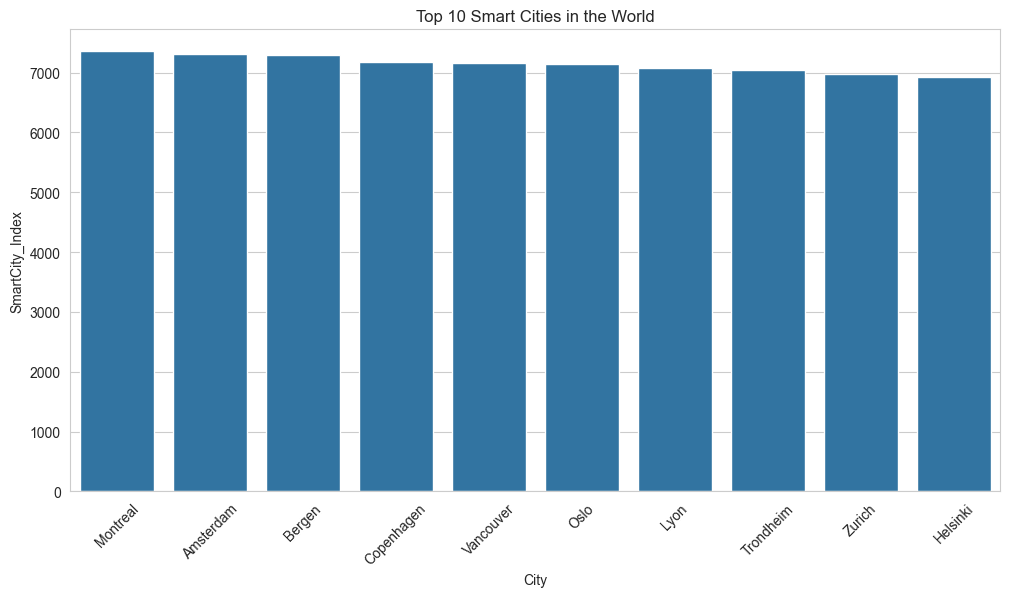

In [5]:
top10 = df.sort_values(by="SmartCity_Index", ascending=False).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x="City",
    y="SmartCity_Index"
)

plt.title("Top 10 Smart Cities in the World")
plt.xticks(rotation=45)

plt.show()

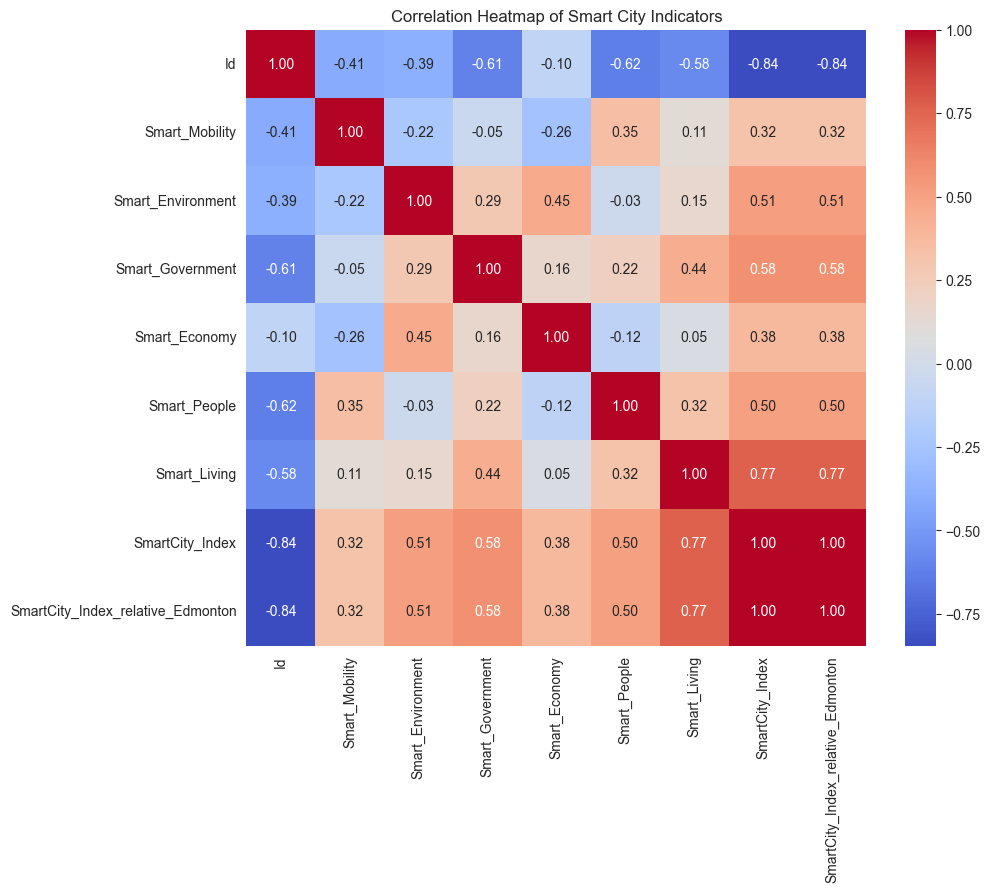

In [6]:
correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Smart City Indicators")

plt.show()

In [7]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [8]:
features = df[[
    "Smart_Mobility",
    "Smart_Environment",
    "Smart_Government",
    "Smart_Economy",
    "Smart_People",
    "Smart_Living"
]]

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

scaled_features[:5]

array([[ 0.59648978,  0.33137863,  1.41342283, -0.87399005,  1.90291105,
         1.1924253 ],
       [ 1.10722416,  0.54355422,  1.26878668, -0.68433223,  1.50900697,
         1.1924253 ],
       [ 1.47392648, -0.22470794,  2.29518054,  1.09510438,  0.84880155,
         0.39687757],
       [ 1.43253796,  1.15210179,  2.46769835, -0.30780567, -0.06522235,
         0.36171524],
       [ 0.30014795,  1.0192006 ,  2.14357397, -1.00507707,  0.6026115 ,
         0.59466568]])

In [9]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

df["Cluster"] = kmeans.fit_predict(scaled_features)

df[["City", "Cluster"]].head()

,City,Cluster
0,Oslo,0
1,Bergen,0
2,Amsterdam,3
3,Copenhagen,0
4,Stockholm,0


In [10]:
df["Cluster"].value_counts()

Cluster
1    43
3    25
2    19
0    15
Name: count, dtype: int64

In [11]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
components = pca.fit_transform(scaled_features)

df["PCA1"] = components[:,0]
df["PCA2"] = components[:,1]

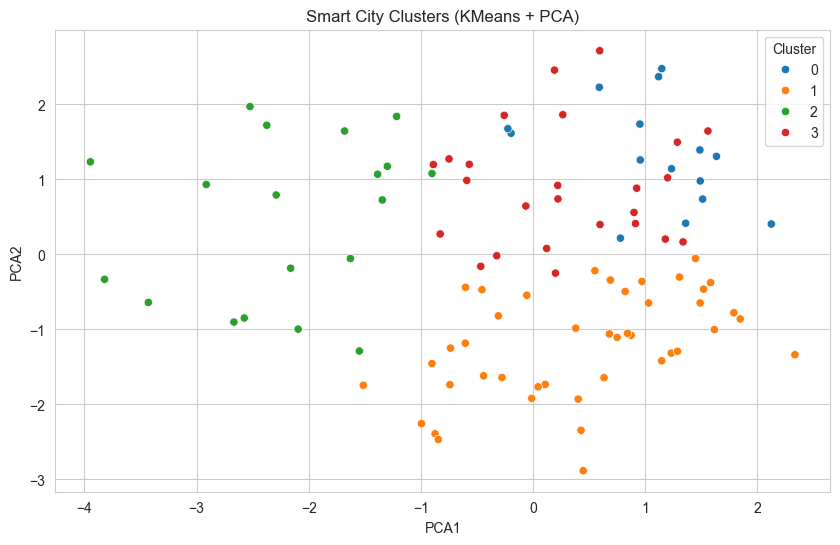

In [12]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette="tab10"
)

plt.title("Smart City Clusters (KMeans + PCA)")
plt.show()

In [13]:
cluster_analysis = df.groupby("Cluster")[[
    "Smart_Mobility",
    "Smart_Environment",
    "Smart_Government",
    "Smart_Economy",
    "Smart_People",
    "Smart_Living",
    "SmartCity_Index"
]].mean()

cluster_analysis

,Smart_Mobility,Smart_Environment,Smart_Government,Smart_Economy,Smart_People,Smart_Living,SmartCity_Index
Cluster,,,,,,,
0,5944.000000,7153.733333,7158.666667,4869.333333,7288.866667,8168.000000,6756.266667
1,4810.465116,6744.511628,5827.534884,7171.976744,4998.279070,5701.162791,5785.046512
2,6348.789474,3602.631579,4941.368421,3442.105263,5437.631579,5202.631579,4967.526316
3,6832.880000,5618.680000,5972.720000,7144.360000,6863.160000,7357.520000,6667.640000


In [14]:
for cluster in sorted(df["Cluster"].unique()):
    print(f"\n--- Cluster {cluster} ---")
    print(df[df["Cluster"] == cluster]["City"].head(10).tolist())


--- Cluster 0 ---
['Oslo', 'Bergen', 'Copenhagen', 'Stockholm', 'Vienna', 'Odense', 'Zurich', 'Trondheim', 'Västerås', 'Aalborg']

--- Cluster 1 ---
['Reykjavik', 'Helsingborg', 'Munich', 'Geneva', 'Luxembourg', 'Turku', 'Hannover', 'Strasbourg', 'Joensuu', 'Frankfurt am Main']

--- Cluster 2 ---
['Adelaide', 'Melbourne', 'Tokyo', 'Perth', 'Osaka', 'Madrid', 'Daejeon', 'Abu Dhabi', 'Seoul', 'Dubai']

--- Cluster 3 ---
['Amsterdam', 'Montreal', 'Singapore', 'Boston', 'Washington, DC', 'Los Angeles', 'Helsinki', 'Vancouver', 'Berlin', 'Toronto']


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [16]:
X = df[[
    "Smart_Mobility",
    "Smart_Environment",
    "Smart_Government",
    "Smart_Economy",
    "Smart_People",
    "Smart_Living"
]]

y = df["SmartCity_Index"]

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(81, 6)
(21, 6)


In [18]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [19]:
predictions = model.predict(X_test)

predictions[:5]

array([6565.33, 6226.86, 5101.81, 6253.67, 6261.78])

In [20]:
mae = mean_absolute_error(y_test, predictions)

r2 = r2_score(y_test, predictions)

print("Mean Absolute Error:", mae)
print("R2 Score:", r2)

Mean Absolute Error: 192.75333333333333
R2 Score: 0.8930972130444514


In [21]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
5,Smart_Living,0.680798
1,Smart_Environment,0.117973
4,Smart_People,0.085488
3,Smart_Economy,0.048494
2,Smart_Government,0.035911
0,Smart_Mobility,0.031337


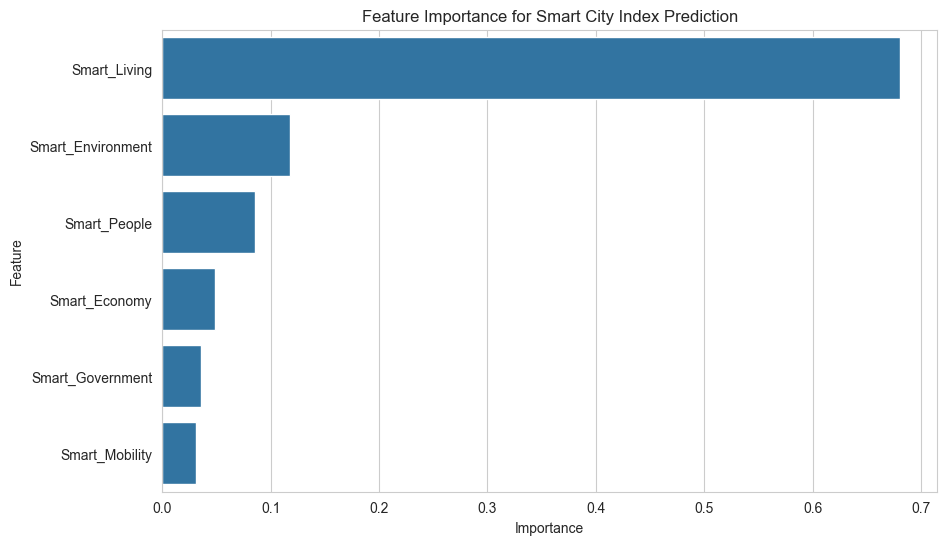

In [22]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance for Smart City Index Prediction")

plt.show()